## 1. Setup, file paths and visual theme

# Traffic-Light Mode Energy and Speed Comparison

Compare two BEB simulation outputs for the same route and same service day:

- Traffic lights ON: `traffic_signals.enabled=true`
- Traffic lights OFF: `traffic_signals.enabled=false`

The notebook checks that the two files are aligned, then plots the change in route-day energy, trip energy, segment intensity, speed profile timing, and duty-level SoC reserve. It is compatible with the refined `beb_soc_model.py` diagnostics, including effective signal stops, modelled signal wait, actual profile time, schedule delay, and infeasible schedule-preservation flags.


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import PercentFormatter
from pathlib import Path
import seaborn as sns
from IPython.display import display

# -----------------------------------------------------------------------------
# Input files
# -----------------------------------------------------------------------------
# Replace WITHOUT_SIGNALS_CSV with the matching run generated with traffic lights OFF.
# The two CSVs should be the same route/date/service selection; only signal mode changes.
WITH_SIGNALS_CSV = Path(r"../data/processed/route_208_trips_2025_07_09.csv")
WITHOUT_SIGNALS_CSV = Path(r"../data/processed/route_208_trips_2025_07_09_no_traffic.csv")

# Keep True for real analysis. For layout testing only, set False and point both
# paths to any compatible sample CSV.
REQUIRE_TWO_FILES = True

# Fallback assumptions used only when analysing older CSVs without exact signal diagnostics.
# Keep these aligned with beb_soc_model.py if you change the model settings.
STOP_PROB_ASSUMED = 0.5
RED_WAIT_S_ASSUMED = 20.0
MAX_SIGNAL_WAIT_SHARE_ASSUMED = 0.35
EPS = 1e-9

SAVE_FIGURES = False
FIG_DIR = Path("../figures/traffic_light_comparison")

# Palette copied from the route 208 analysis notebook.
INK   = "#1f2433"
OFF   = "#2a9d8f"   # signals off
ON    = "#e76f51"   # signals on
ACC   = "#3d5a80"
ACC2  = "#ee9b00"
REGEN = "#52b788"
GRID  = "#dde1e7"
MUTED = "#6b7280"
SEQ   = "mako"
DIV   = "vlag"

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 160,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.edgecolor": INK, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": INK, "ytick.color": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 10,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.axisbelow": True, "legend.frameon": False,
})

def titled(ax, title, subtitle=None):
    """Apply a two-line axis heading without title/subtitle overlap.

    The previous version used ax.set_title() plus a subtitle at y=1.02.
    On multi-panel figures, that placed the title and subtitle in the same
    vertical band. Here the title is padded upward and the subtitle is anchored
    just below it, with clip_on=False so tight exports keep both lines.
    """
    ax.set_title(title, loc="left", pad=26, fontsize=13, fontweight="bold")
    if subtitle:
        ax.text(0.0, 1.025, subtitle, transform=ax.transAxes,
                fontsize=9.2, color=MUTED, ha="left", va="bottom",
                clip_on=False)
    return ax

def tidy_layout(fig, top=0.86):
    """Consistent spacing for plots with custom subtitles above axes."""
    fig.tight_layout(pad=2.8, w_pad=2.6, h_pad=3.0)
    fig.subplots_adjust(top=top)

def savefig(fig, name):
    if SAVE_FIGURES:
        FIG_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight")

def delta_label(delta, base):
    if pd.isna(delta) or pd.isna(base) or abs(base) < 1e-12:
        return "n/a"
    return f"{delta:+.2f} ({delta/base*100:+.1f}%)"


## 2. Load, normalize and check pairing

In [16]:

def gtfs_seconds(value):
    """GTFS times may exceed 24:00:00; return seconds from service-day midnight."""
    if pd.isna(value):
        return np.nan
    parts = str(value).split(":")
    if len(parts) < 2:
        return np.nan
    h = int(float(parts[0]))
    m = int(float(parts[1]))
    s = int(float(parts[2])) if len(parts) > 2 else 0
    return h * 3600 + m * 60 + s

def numeric_series(df, col, default=np.nan):
    """Return a numeric Series, creating a default column when absent."""
    if col not in df.columns:
        df[col] = default
    df[col] = pd.to_numeric(df[col], errors="coerce")
    return df[col]

def safe_rate_kmh(length_m, time_s):
    """Convert distance/time to km/h while avoiding divide-by-zero warnings."""
    length_m = pd.to_numeric(length_m, errors="coerce")
    time_s = pd.to_numeric(time_s, errors="coerce")
    return np.where(time_s > EPS, length_m / time_s * 3.6, np.nan)

def safe_bool_series(s):
    """Coerce bool-like CSV values to boolean; missing values become False."""
    if s is None:
        return pd.Series(dtype=bool)
    if s.dtype == bool:
        return s.fillna(False)
    text = s.astype(str).str.strip().str.lower()
    return text.isin(["true", "1", "yes", "y", "t"])

def normalize_energy_schema(df, mode):
    """
    Harmonise old and refined BEB result CSVs.

    The refined model exports exact timing/speed diagnostics. Older CSVs are still
    loadable, but timing diagnostics are marked as unavailable or estimated.
    """
    df = df.copy()
    original_columns = set(df.columns)
    df["mode"] = mode

    # Base columns
    numeric_series(df, "length_m", 0.0)
    numeric_series(df, "run_time_s", np.nan)
    numeric_series(df, "dwell_s", 0.0)
    numeric_series(df, "n_signals", 0.0)
    numeric_series(df, "net_battery_energy_kWh", 0.0)
    numeric_series(df, "gross_consumed_kWh", 0.0)
    numeric_series(df, "regen_recovered_kWh", 0.0)
    numeric_series(df, "aux_energy_kWh", 0.0)

    df["dist_km"] = df["length_m"] / 1000.0
    df["scheduled_run_time_s"] = (
        pd.to_numeric(df["scheduled_run_time_s"], errors="coerce")
        if "scheduled_run_time_s" in original_columns
        else df["run_time_s"]
    )

    # Exact refined diagnostics, or conservative fallbacks for older files.
    if "n_effective_signal_stops" not in original_columns:
        df["n_effective_signal_stops"] = np.where(
            mode == "Signals on",
            df["n_signals"].fillna(0.0) * STOP_PROB_ASSUMED,
            0.0,
        )
    else:
        numeric_series(df, "n_effective_signal_stops", 0.0)

    if "signal_wait_requested_s" not in original_columns:
        df["signal_wait_requested_s"] = np.where(
            mode == "Signals on",
            df["n_effective_signal_stops"] * RED_WAIT_S_ASSUMED,
            0.0,
        )
    else:
        numeric_series(df, "signal_wait_requested_s", 0.0)

    if "signal_wait_s" not in original_columns:
        wait_cap = df["scheduled_run_time_s"] * MAX_SIGNAL_WAIT_SHARE_ASSUMED
        df["signal_wait_s"] = np.where(
            mode == "Signals on",
            np.minimum(df["signal_wait_requested_s"], wait_cap),
            0.0,
        )
    else:
        numeric_series(df, "signal_wait_s", 0.0)

    if "signal_wait_reduced_s" not in original_columns:
        df["signal_wait_reduced_s"] = (
            df["signal_wait_requested_s"] - df["signal_wait_s"]
        ).clip(lower=0.0)
    else:
        numeric_series(df, "signal_wait_reduced_s", 0.0)

    if "actual_profile_time_s" not in original_columns:
        df["actual_profile_time_s"] = np.nan
    else:
        numeric_series(df, "actual_profile_time_s", np.nan)

    if "moving_profile_time_s" not in original_columns:
        df["moving_profile_time_s"] = (
            df["actual_profile_time_s"] - df["signal_wait_s"]
        ).where(df["actual_profile_time_s"].notna(), np.nan)
    else:
        numeric_series(df, "moving_profile_time_s", np.nan)

    if "schedule_delay_s" not in original_columns:
        df["schedule_delay_s"] = (
            df["actual_profile_time_s"] - df["scheduled_run_time_s"]
        ).clip(lower=0.0)
    else:
        numeric_series(df, "schedule_delay_s", 0.0)

    if "schedule_infeasible" not in original_columns:
        df["schedule_infeasible"] = np.where(
            df["schedule_delay_s"].notna(),
            df["schedule_delay_s"] > EPS,
            False,
        )
    else:
        df["schedule_infeasible"] = safe_bool_series(df["schedule_infeasible"])

    if "speed_cap_ms" not in original_columns:
        df["speed_cap_ms"] = np.nan
    else:
        numeric_series(df, "speed_cap_ms", np.nan)

    if "min_feasible_motion_time_s" not in original_columns:
        df["min_feasible_motion_time_s"] = np.nan
    else:
        numeric_series(df, "min_feasible_motion_time_s", np.nan)

    if "aux_total_time_s" not in original_columns:
        df["aux_total_time_s"] = (
            df["actual_profile_time_s"] + df["dwell_s"]
        ).where(df["actual_profile_time_s"].notna(), np.nan)
    else:
        numeric_series(df, "aux_total_time_s", np.nan)

    if "aux_power_kW" not in original_columns:
        df["aux_power_kW"] = np.where(
            df["aux_total_time_s"] > EPS,
            df["aux_energy_kWh"] / (df["aux_total_time_s"] / 3600.0),
            np.nan,
        )
    else:
        numeric_series(df, "aux_power_kW", np.nan)

    # Speed diagnostics
    df["scheduled_speed_kmh"] = safe_rate_kmh(df["length_m"], df["scheduled_run_time_s"])
    df["actual_profile_speed_kmh"] = safe_rate_kmh(df["length_m"], df["actual_profile_time_s"])
    df["moving_profile_speed_kmh"] = safe_rate_kmh(df["length_m"], df["moving_profile_time_s"])
    df["speed_cap_kmh"] = df["speed_cap_ms"] * 3.6
    df["speed_loss_kmh"] = df["actual_profile_speed_kmh"] - df["scheduled_speed_kmh"]
    df["schedule_delay_share_%"] = np.where(
        df["scheduled_run_time_s"] > EPS,
        df["schedule_delay_s"] / df["scheduled_run_time_s"] * 100,
        np.nan,
    )
    df["signal_wait_share_%"] = np.where(
        df["scheduled_run_time_s"] > EPS,
        df["signal_wait_s"] / df["scheduled_run_time_s"] * 100,
        np.nan,
    )

    df["dir_label"] = (
        df["direction_id"].map({0: "Outbound", 1: "Inbound"})
        .fillna(df["direction_id"].astype(str))
        if "direction_id" in df.columns
        else "unknown"
    )
    df["dep_s"] = df["trip_start_time"].map(gtfs_seconds) if "trip_start_time" in df.columns else np.nan
    df["dep_hour"] = (df["dep_s"] // 3600).astype("Int64")
    df["is_regen"] = df["net_battery_energy_kWh"] < 0
    if "signal_source" not in df.columns:
        df["signal_source"] = "none"

    # Store source availability flags for later reporting.
    for col in [
        "n_effective_signal_stops", "signal_wait_s", "signal_wait_requested_s",
        "signal_wait_reduced_s", "actual_profile_time_s", "moving_profile_time_s",
        "schedule_delay_s", "schedule_infeasible", "speed_cap_ms",
        "min_feasible_motion_time_s", "aux_total_time_s",
    ]:
        df[f"_input_had_{col}"] = col in original_columns

    return df

def require_file(path, label):
    if not Path(path).is_file():
        msg = f"{label} CSV not found: {path}"
        if REQUIRE_TWO_FILES:
            raise FileNotFoundError(msg + "\nSet the path in the first code cell, then rerun.")
        print("WARNING:", msg)
    return Path(path)

require_file(WITH_SIGNALS_CSV, "WITH_SIGNALS_CSV")
require_file(WITHOUT_SIGNALS_CSV, "WITHOUT_SIGNALS_CSV")

on_raw = pd.read_csv(WITH_SIGNALS_CSV)
off_raw = pd.read_csv(WITHOUT_SIGNALS_CSV)
input_columns = {
    "Signals on": set(on_raw.columns),
    "Signals off": set(off_raw.columns),
}

on = normalize_energy_schema(on_raw, "Signals on")
off = normalize_energy_schema(off_raw, "Signals off")
all_df = pd.concat([off, on], ignore_index=True)

checks = pd.Series({
    "route_short_name": off["route_short_name"].iloc[0] == on["route_short_name"].iloc[0],
    "simulation_date": off["simulation_date"].iloc[0] == on["simulation_date"].iloc[0],
    "trip_count": off["trip_id"].nunique() == on["trip_id"].nunique(),
    "segment_rows": len(off) == len(on),
    "segment_keys": set(zip(off.trip_id, off.segment)) == set(zip(on.trip_id, on.segment)),
})
print("Pairing checks")
print(checks.to_string())
if not checks.all():
    print("\nWARNING: at least one pairing check failed. Delta plots use inner joins only.")

route_name = f"{on.route_short_name.iloc[0]} - {on.route_long_name.iloc[0]}"
service_date = str(on.simulation_date.iloc[0])
print(f"\nLoaded route {route_name} | date {service_date}")
print(f"Rows: off={len(off):,}, on={len(on):,} | trips: off={off.trip_id.nunique():,}, on={on.trip_id.nunique():,}")

diagnostic_cols = [
    "n_effective_signal_stops", "signal_wait_s", "signal_wait_requested_s",
    "signal_wait_reduced_s", "actual_profile_time_s", "moving_profile_time_s",
    "schedule_delay_s", "schedule_infeasible", "speed_cap_ms",
]
available = [c for c in diagnostic_cols if c in input_columns["Signals on"] or c in input_columns["Signals off"]]
missing = [c for c in diagnostic_cols if c not in available]
print("\nRefined diagnostic columns detected:")
print("  available:", ", ".join(available) if available else "none")
print("  missing:  ", ", ".join(missing) if missing else "none")


Pairing checks
route_short_name    True
simulation_date     True
trip_count          True
segment_rows        True
segment_keys        True

Loaded route 208 - Lotabeg - Bishopstown - Curraheen | date 2025-07-09
Rows: off=7,561, on=7,561 | trips: off=206, on=206

Refined diagnostic columns detected:
  available: n_effective_signal_stops, signal_wait_s, signal_wait_requested_s, signal_wait_reduced_s, actual_profile_time_s, moving_profile_time_s, schedule_delay_s, schedule_infeasible, speed_cap_ms
  missing:   none


## 3. Build paired segment, trip and duty tables

In [17]:

def sum_min1(s):
    return pd.to_numeric(s, errors="coerce").sum(min_count=1)

def mean_numeric(s):
    return pd.to_numeric(s, errors="coerce").mean()

def bool_count(s):
    return safe_bool_series(s).sum()

def make_trip_table(df):
    out = (df.groupby(["mode", "trip_id"], observed=True)
        .agg(route_short_name=("route_short_name", "first"),
             route_long_name=("route_long_name", "first"),
             simulation_date=("simulation_date", "first"),
             duty_id=("duty_id", "first"),
             duty_trip_index=("duty_trip_index", "first"),
             direction_id=("direction_id", "first"),
             dir_label=("dir_label", "first"),
             dep_s=("dep_s", "first"), dep_hour=("dep_hour", "first"),
             trip_start_time=("trip_start_time", "first"),
             segments=("segment", "count"),
             dist_km=("dist_km", "sum"),
             run_min=("run_time_s", lambda s: s.sum()/60),
             dwell_min=("dwell_s", lambda s: s.sum()/60),
             scheduled_run_s=("scheduled_run_time_s", sum_min1),
             actual_profile_s=("actual_profile_time_s", sum_min1),
             moving_profile_s=("moving_profile_time_s", sum_min1),
             schedule_delay_s=("schedule_delay_s", sum_min1),
             signal_wait_s=("signal_wait_s", sum_min1),
             signal_wait_requested_s=("signal_wait_requested_s", sum_min1),
             signal_wait_reduced_s=("signal_wait_reduced_s", sum_min1),
             effective_signal_stops=("n_effective_signal_stops", sum_min1),
             infeasible_segments=("schedule_infeasible", bool_count),
             speed_cap_kmh=("speed_cap_kmh", mean_numeric),
             n_signals=("n_signals", "sum"),
             pax_mean=("passengers", "mean"),
             net_kWh=("net_battery_energy_kWh", "sum"),
             gross_kWh=("gross_consumed_kWh", "sum"),
             regen_kWh=("regen_recovered_kWh", "sum"),
             aux_kWh=("aux_energy_kWh", "sum"),
             aux_total_time_s=("aux_total_time_s", sum_min1),
             aux_power_kW_mean=("aux_power_kW", mean_numeric),
             soc0=("trip_start_soc_%", "first"),
             soc1=("trip_end_soc_%", "first"))
        .reset_index())
    out["kWh_per_km"] = out["net_kWh"] / out["dist_km"]
    out["duration_min"] = out["run_min"] + out["dwell_min"]
    out["scheduled_run_min"] = out["scheduled_run_s"] / 60
    out["actual_profile_min"] = out["actual_profile_s"] / 60
    out["moving_profile_min"] = out["moving_profile_s"] / 60
    out["schedule_delay_min"] = out["schedule_delay_s"] / 60
    out["signal_wait_min"] = out["signal_wait_s"] / 60
    out["signal_wait_requested_min"] = out["signal_wait_requested_s"] / 60
    out["signal_wait_reduced_min"] = out["signal_wait_reduced_s"] / 60
    out["scheduled_speed_kmh"] = out["dist_km"] / (out["scheduled_run_s"] / 3600)
    out["actual_profile_speed_kmh"] = out["dist_km"] / (out["actual_profile_s"] / 3600)
    out["moving_profile_speed_kmh"] = out["dist_km"] / (out["moving_profile_s"] / 3600)
    out["infeasible_segments_%"] = out["infeasible_segments"] / out["segments"] * 100
    out["effective_stops_per_km"] = out["effective_signal_stops"] / out["dist_km"]
    out["signal_wait_s_per_km"] = out["signal_wait_s"] / out["dist_km"]
    return out

def make_duty_table(df):
    out = (df.sort_values(["duty_id", "duty_trip_index", "segment"])
        .groupby(["mode", "duty_id"], observed=True)
        .agg(trips=("trip_id", "nunique"), segments=("segment", "count"), dist_km=("dist_km", "sum"),
             net_kWh=("net_battery_energy_kWh", "sum"), n_signals=("n_signals", "sum"),
             scheduled_run_s=("scheduled_run_time_s", sum_min1),
             actual_profile_s=("actual_profile_time_s", sum_min1),
             schedule_delay_s=("schedule_delay_s", sum_min1),
             signal_wait_s=("signal_wait_s", sum_min1),
             effective_signal_stops=("n_effective_signal_stops", sum_min1),
             infeasible_segments=("schedule_infeasible", bool_count),
             start_time=("trip_start_time", "first"), soc_start=("SoC_start_%", "first"),
             soc_end=("SoC_end_%", "last"), soc_min=("SoC_end_%", "min"))
        .reset_index())
    out["kWh_per_km"] = out["net_kWh"] / out["dist_km"]
    out["scheduled_speed_kmh"] = out["dist_km"] / (out["scheduled_run_s"] / 3600)
    out["actual_profile_speed_kmh"] = out["dist_km"] / (out["actual_profile_s"] / 3600)
    out["schedule_delay_min"] = out["schedule_delay_s"] / 60
    out["signal_wait_min"] = out["signal_wait_s"] / 60
    out["infeasible_segments_%"] = out["infeasible_segments"] / out["segments"] * 100
    return out

trips = make_trip_table(all_df)
duties = make_duty_table(all_df)

base_seg_cols = [
    "trip_id", "segment", "direction_id", "dir_label", "dep_s", "dep_hour",
    "dist_km", "length_m", "grade_%", "passengers", "n_signals",
    "scheduled_run_time_s", "actual_profile_time_s", "moving_profile_time_s",
    "schedule_delay_s", "signal_wait_s", "signal_wait_requested_s",
    "signal_wait_reduced_s", "n_effective_signal_stops", "schedule_infeasible",
    "scheduled_speed_kmh", "actual_profile_speed_kmh", "moving_profile_speed_kmh",
    "speed_cap_kmh", "speed_loss_kmh", "signal_wait_share_%",
    "schedule_delay_share_%", "min_feasible_motion_time_s", "aux_total_time_s",
    "aux_power_kW",
    "net_battery_energy_kWh", "gross_consumed_kWh", "regen_recovered_kWh",
    "aux_energy_kWh", "net_battery_kWh_per_km", "SoC_start_%", "SoC_end_%"
]
seg_cols = [c for c in base_seg_cols if c in off.columns and c in on.columns]
seg_pair = off[seg_cols].merge(on[seg_cols], on=["trip_id", "segment"], suffixes=("_off", "_on"), how="inner")

for col in [
    "net_battery_energy_kWh", "net_battery_kWh_per_km", "gross_consumed_kWh",
    "regen_recovered_kWh", "aux_energy_kWh", "n_signals", "scheduled_run_time_s",
    "actual_profile_time_s", "moving_profile_time_s", "schedule_delay_s",
    "signal_wait_s", "signal_wait_requested_s", "signal_wait_reduced_s",
    "n_effective_signal_stops", "scheduled_speed_kmh", "actual_profile_speed_kmh",
    "moving_profile_speed_kmh", "speed_loss_kmh", "aux_total_time_s"
]:
    if f"{col}_on" in seg_pair.columns and f"{col}_off" in seg_pair.columns:
        seg_pair[f"delta_{col}"] = seg_pair[f"{col}_on"] - seg_pair[f"{col}_off"]

seg_pair["delta_pct_energy"] = (
    seg_pair["delta_net_battery_energy_kWh"]
    / seg_pair["net_battery_energy_kWh_off"].replace(0, np.nan) * 100
)

trip_pair = trips[trips["mode"] == "Signals off"].merge(
    trips[trips["mode"] == "Signals on"],
    on="trip_id", suffixes=("_off", "_on"), how="inner"
)
for col in [
    "net_kWh", "kWh_per_km", "gross_kWh", "regen_kWh", "aux_kWh", "n_signals",
    "soc1", "scheduled_speed_kmh", "actual_profile_speed_kmh",
    "moving_profile_speed_kmh", "actual_profile_min", "schedule_delay_min",
    "signal_wait_min", "signal_wait_requested_min", "signal_wait_reduced_min",
    "effective_signal_stops", "infeasible_segments", "effective_stops_per_km",
    "signal_wait_s_per_km"
]:
    if f"{col}_on" in trip_pair.columns and f"{col}_off" in trip_pair.columns:
        trip_pair[f"delta_{col}"] = trip_pair[f"{col}_on"] - trip_pair[f"{col}_off"]
trip_pair["delta_pct_energy"] = (
    trip_pair["delta_net_kWh"] / trip_pair["net_kWh_off"].replace(0, np.nan) * 100
)

duty_pair = duties[duties["mode"] == "Signals off"].merge(
    duties[duties["mode"] == "Signals on"],
    on="duty_id", suffixes=("_off", "_on"), how="inner"
)
for col in [
    "net_kWh", "kWh_per_km", "soc_end", "soc_min", "n_signals",
    "scheduled_speed_kmh", "actual_profile_speed_kmh", "schedule_delay_min",
    "signal_wait_min", "effective_signal_stops", "infeasible_segments"
]:
    if f"{col}_on" in duty_pair.columns and f"{col}_off" in duty_pair.columns:
        duty_pair[f"delta_{col}"] = duty_pair[f"{col}_on"] - duty_pair[f"{col}_off"]

print(f"Paired segments: {len(seg_pair):,}")
print(f"Paired trips:    {len(trip_pair):,}")
print(f"Paired duties:   {len(duty_pair):,}")


Paired segments: 7,561
Paired trips:    206
Paired duties:   16


C:\Users\ninglin.ou\AppData\Local\Temp\ipykernel_2628\4051492310.py:133: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  trip_pair[f"delta_{col}"] = trip_pair[f"{col}_on"] - trip_pair[f"{col}_off"]
C:\Users\ninglin.ou\AppData\Local\Temp\ipykernel_2628\4051492310.py:133: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  trip_pair[f"delta_{col}"] = trip_pair[f"{col}_on"] - trip_pair[f"{col}_off"]
C:\Users\ninglin.ou\AppData\Local\Temp\ipykernel_2628\4051492310.py:133: PerformanceWarning: DataFrame is highly fragmented.  This is usually 

## 4. Executive comparison

In [18]:

# -------------------------------------------------------------------
# Enhanced ON/OFF summary with traffic-light, timing and speed diagnostics
# -------------------------------------------------------------------

df = all_df.copy()

def source_status(col, fallback):
    modes = [mode for mode, cols in input_columns.items() if col in cols]
    if modes:
        return f"exact from `{col}` ({', '.join(modes)})"
    return fallback

print("Diagnostic sources:")
print("- effective signal stops:", source_status(
    "n_effective_signal_stops", f"estimated as n_signals × {STOP_PROB_ASSUMED}"
))
print("- signal wait:", source_status(
    "signal_wait_s",
    f"estimated as min(effective_stops × {RED_WAIT_S_ASSUMED}s, "
    f"{MAX_SIGNAL_WAIT_SHARE_ASSUMED:.0%} × run_time_s)"
))
print("- requested signal wait:", source_status(
    "signal_wait_requested_s", f"estimated as effective_stops × {RED_WAIT_S_ASSUMED}s"
))
print("- reduced signal wait:", source_status(
    "signal_wait_reduced_s", "derived as requested wait - modelled wait"
))
print("- actual profile time:", source_status(
    "actual_profile_time_s", "not available in CSV"
))
print("- schedule delay:", source_status(
    "schedule_delay_s", "derived from actual_profile_time_s - scheduled_run_time_s when possible"
))
print("- infeasible segments:", source_status(
    "schedule_infeasible", "derived from schedule_delay_s > 0 when possible"
))
print("- speed cap:", source_status(
    "speed_cap_ms", "not available in CSV"
))

def safe_sum(g, col):
    return pd.to_numeric(g[col], errors="coerce").sum(min_count=1)

def safe_mean(g, col):
    return pd.to_numeric(g[col], errors="coerce").mean()

def safe_min(g, col):
    return pd.to_numeric(g[col], errors="coerce").min()

def safe_nunique(g, col):
    return g[col].nunique() if col in g.columns else np.nan

def route_avg_speed(dist_km, seconds):
    return dist_km / (seconds / 3600) if pd.notna(seconds) and seconds > EPS else np.nan

def summarise_mode(g):
    segments = len(g)
    trips_n = safe_nunique(g, "trip_id")
    duties_n = safe_nunique(g, "duty_id")
    dist_km = safe_sum(g, "dist_km")
    n_signals = safe_sum(g, "n_signals")

    net = safe_sum(g, "net_battery_energy_kWh")
    gross = safe_sum(g, "gross_consumed_kWh")
    regen = safe_sum(g, "regen_recovered_kWh")
    aux = safe_sum(g, "aux_energy_kWh")

    scheduled_run_time_s = safe_sum(g, "scheduled_run_time_s")
    actual_profile_time_s = safe_sum(g, "actual_profile_time_s")
    moving_profile_time_s = safe_sum(g, "moving_profile_time_s")
    schedule_delay_s = safe_sum(g, "schedule_delay_s")
    signal_wait_s = safe_sum(g, "signal_wait_s")
    signal_wait_requested_s = safe_sum(g, "signal_wait_requested_s")
    signal_wait_reduced_s = safe_sum(g, "signal_wait_reduced_s")
    effective_stops = safe_sum(g, "n_effective_signal_stops")
    aux_total_time_s = safe_sum(g, "aux_total_time_s")

    infeasible_segments = safe_bool_series(g["schedule_infeasible"]).sum()
    signal_segments = (g["n_signals"].fillna(0) > 0).sum()

    return pd.Series({
        # Existing headline rows
        "segments": segments,
        "trips": trips_n,
        "duties": duties_n,
        "dist_km": dist_km,
        "n_signals": n_signals,

        "net_kWh": net,
        "gross_kWh": gross,
        "regen_kWh": regen,
        "aux_kWh": aux,
        "final_soc_min": safe_min(g, "SoC_end_%"),

        "kWh_per_km": net / dist_km if dist_km > 0 else np.nan,
        "regen_share_%": regen / (gross + aux) * 100 if (gross + aux) > 0 else np.nan,

        # Energy-accounting diagnostic
        "energy_balance_error_kWh": net - (gross + aux - regen),

        # Traffic-light diagnostics
        "signal_segments": signal_segments,
        "signal_segments_%": signal_segments / segments * 100 if segments > 0 else np.nan,
        "signal_density_per_km": n_signals / dist_km if dist_km > 0 else np.nan,

        "effective_signal_stops": effective_stops,
        "effective_stop_rate_%": effective_stops / n_signals * 100 if n_signals > 0 else np.nan,

        "signal_wait_requested_h": signal_wait_requested_s / 3600 if pd.notna(signal_wait_requested_s) else np.nan,
        "signal_wait_h": signal_wait_s / 3600 if pd.notna(signal_wait_s) else np.nan,
        "signal_wait_reduced_h": signal_wait_reduced_s / 3600 if pd.notna(signal_wait_reduced_s) else np.nan,
        "signal_wait_s_per_trip": signal_wait_s / trips_n if pd.notna(signal_wait_s) and trips_n > 0 else np.nan,
        "signal_wait_s_per_km": signal_wait_s / dist_km if pd.notna(signal_wait_s) and dist_km > 0 else np.nan,
        "signal_wait_s_per_effective_stop": signal_wait_s / effective_stops if pd.notna(signal_wait_s) and effective_stops > 0 else np.nan,

        # Time and speed diagnostics
        "scheduled_run_time_h": scheduled_run_time_s / 3600 if pd.notna(scheduled_run_time_s) else np.nan,
        "actual_profile_time_h": actual_profile_time_s / 3600 if pd.notna(actual_profile_time_s) else np.nan,
        "moving_profile_time_h": moving_profile_time_s / 3600 if pd.notna(moving_profile_time_s) else np.nan,
        "schedule_delay_h": schedule_delay_s / 3600 if pd.notna(schedule_delay_s) else np.nan,
        "schedule_delay_s_per_trip": schedule_delay_s / trips_n if pd.notna(schedule_delay_s) and trips_n > 0 else np.nan,
        "aux_total_time_h": aux_total_time_s / 3600 if pd.notna(aux_total_time_s) else np.nan,

        "scheduled_avg_speed_kmh": route_avg_speed(dist_km, scheduled_run_time_s),
        "actual_profile_avg_speed_kmh": route_avg_speed(dist_km, actual_profile_time_s),
        "moving_avg_speed_kmh": route_avg_speed(dist_km, moving_profile_time_s),
        "mean_speed_cap_kmh": safe_mean(g, "speed_cap_kmh"),
        "mean_segment_speed_loss_kmh": safe_mean(g, "speed_loss_kmh"),
        "mean_signal_wait_share_%": safe_mean(g, "signal_wait_share_%"),
        "mean_schedule_delay_share_%": safe_mean(g, "schedule_delay_share_%"),

        "infeasible_segments": infeasible_segments,
        "infeasible_segments_%": infeasible_segments / segments * 100 if segments > 0 else np.nan,
    })

summary = (
    df.groupby("mode", observed=True)
      .apply(summarise_mode)
      .reindex(["Signals off", "Signals on"])
)

# -------------------------------------------------------------------
# ON - OFF comparison table
# -------------------------------------------------------------------

compare = summary.T
compare["delta_on_minus_off"] = compare["Signals on"] - compare["Signals off"]
compare["delta_%"] = (
    compare["delta_on_minus_off"]
    / compare["Signals off"].replace(0, np.nan)
    * 100
)

# Avoid misleading relative deltas for percentage-point / diagnostic rows.
rows_where_relative_delta_is_misleading = [
    "final_soc_min",
    "regen_share_%",
    "signal_segments_%",
    "effective_stop_rate_%",
    "infeasible_segments_%",
    "energy_balance_error_kWh",
    "mean_signal_wait_share_%",
    "mean_schedule_delay_share_%",
]
compare.loc[
    compare.index.intersection(rows_where_relative_delta_is_misleading),
    "delta_%"
] = np.nan

display(compare.round(3))

# -------------------------------------------------------------------
# Extra derived ON/OFF diagnostics
# -------------------------------------------------------------------

net_delta = compare.loc["net_kWh", "delta_on_minus_off"]
gross_delta = compare.loc["gross_kWh", "delta_on_minus_off"]
aux_delta = compare.loc["aux_kWh", "delta_on_minus_off"]
regen_delta = compare.loc["regen_kWh", "delta_on_minus_off"]
stop_start_delta = gross_delta - regen_delta

effective_stops_on = summary.loc["Signals on", "effective_signal_stops"]
signal_wait_delta_h = compare.loc["signal_wait_h", "delta_on_minus_off"]
schedule_delay_delta_h = compare.loc["schedule_delay_h", "delta_on_minus_off"]
requested_wait_on_h = summary.loc["Signals on", "signal_wait_requested_h"]
reduced_wait_on_h = summary.loc["Signals on", "signal_wait_reduced_h"]

derived_diagnostics = pd.Series({
    "stop_start_delta_kWh_gross_minus_regen": stop_start_delta,
    "stop_start_share_of_net_delta_%": stop_start_delta / net_delta * 100 if abs(net_delta) > EPS else np.nan,
    "aux_share_of_net_delta_%": aux_delta / net_delta * 100 if abs(net_delta) > EPS else np.nan,

    "net_delta_Wh_per_effective_stop": net_delta * 1000 / effective_stops_on if effective_stops_on > 0 else np.nan,
    "gross_delta_Wh_per_effective_stop": gross_delta * 1000 / effective_stops_on if effective_stops_on > 0 else np.nan,
    "regen_delta_Wh_per_effective_stop": regen_delta * 1000 / effective_stops_on if effective_stops_on > 0 else np.nan,
    "aux_delta_Wh_per_effective_stop": aux_delta * 1000 / effective_stops_on if effective_stops_on > 0 else np.nan,

    "aux_delta_kWh_per_signal_wait_hour": aux_delta / signal_wait_delta_h if pd.notna(signal_wait_delta_h) and signal_wait_delta_h > EPS else np.nan,
    "aux_delta_kWh_per_schedule_delay_hour": aux_delta / schedule_delay_delta_h if pd.notna(schedule_delay_delta_h) and schedule_delay_delta_h > EPS else np.nan,
    "modelled_wait_s_per_effective_stop": summary.loc["Signals on", "signal_wait_s_per_effective_stop"],
    "requested_wait_reduced_%": reduced_wait_on_h / requested_wait_on_h * 100 if pd.notna(requested_wait_on_h) and requested_wait_on_h > EPS else np.nan,
})

display(derived_diagnostics.to_frame("value").round(3))


Diagnostic sources:
- effective signal stops: exact from `n_effective_signal_stops` (Signals on, Signals off)
- signal wait: exact from `signal_wait_s` (Signals on, Signals off)
- requested signal wait: exact from `signal_wait_requested_s` (Signals on, Signals off)
- reduced signal wait: exact from `signal_wait_reduced_s` (Signals on, Signals off)
- actual profile time: exact from `actual_profile_time_s` (Signals on, Signals off)
- schedule delay: exact from `schedule_delay_s` (Signals on, Signals off)
- infeasible segments: exact from `schedule_infeasible` (Signals on, Signals off)
- speed cap: exact from `speed_cap_ms` (Signals on, Signals off)


mode,Signals off,Signals on,delta_on_minus_off,delta_%
segments,7561.000,7561.000,0.000,0.000
trips,206.000,206.000,0.000,0.000
duties,16.000,16.000,0.000,0.000
dist_km,2463.241,2463.241,0.000,0.000
n_signals,0.000,0.000,0.000,NaN
net_kWh,3796.603,3829.825,33.222,0.875
gross_kWh,4349.320,4404.321,55.001,1.265
regen_kWh,1032.812,1060.111,27.299,2.643
aux_kWh,480.250,485.729,5.479,1.141
final_soc_min,6.130,5.140,-0.990,NaN


,value
stop_start_delta_kWh_gross_minus_regen,27.702
stop_start_share_of_net_delta_%,83.385
aux_share_of_net_delta_%,16.492
net_delta_Wh_per_effective_stop,18.055
gross_delta_Wh_per_effective_stop,29.892
regen_delta_Wh_per_effective_stop,14.836
aux_delta_Wh_per_effective_stop,2.978
aux_delta_kWh_per_signal_wait_hour,3.262
aux_delta_kWh_per_schedule_delay_hour,2.989
modelled_wait_s_per_effective_stop,3.286


## 5. Speed and schedule-preservation diagnostics

This section checks whether the signal mode preserves the GTFS schedule, how much actual profile time is added, and where speed-cap infeasibility appears.

,scheduled_avg_speed_kmh,actual_profile_avg_speed_kmh,moving_avg_speed_kmh,mean_speed_cap_kmh,scheduled_run_time_h,actual_profile_time_h,moving_profile_time_h,signal_wait_requested_h,signal_wait_h,signal_wait_reduced_h,schedule_delay_h,schedule_delay_s_per_trip,infeasible_segments,infeasible_segments_%
mode,,,,,,,,,,,,,,
Signals off,17.334,17.334,17.334,0.000,142.108,142.108,142.108,0.000,0.00,0.000,0.000,0.000,0.0,0.000
Signals on,17.334,17.113,17.315,4.543,142.108,143.942,142.262,7.078,1.68,5.399,1.833,32.037,929.0,12.287


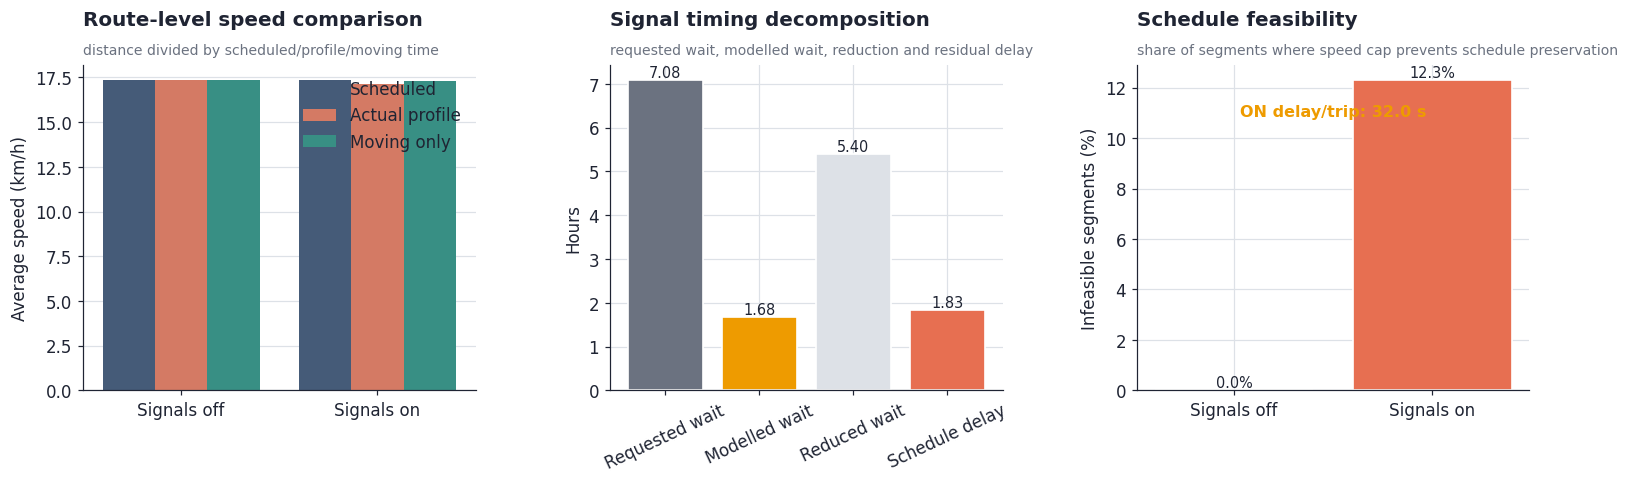

In [19]:

speed_cols = [
    "scheduled_avg_speed_kmh",
    "actual_profile_avg_speed_kmh",
    "moving_avg_speed_kmh",
    "mean_speed_cap_kmh",
    "scheduled_run_time_h",
    "actual_profile_time_h",
    "moving_profile_time_h",
    "signal_wait_requested_h",
    "signal_wait_h",
    "signal_wait_reduced_h",
    "schedule_delay_h",
    "schedule_delay_s_per_trip",
    "infeasible_segments",
    "infeasible_segments_%",
]
speed_diag_table = summary[speed_cols].copy()
display(speed_diag_table.round(3))

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.8))

# 1) Route-level average speed comparison
ax = axes[0]
speed_long = (
    summary[["scheduled_avg_speed_kmh", "actual_profile_avg_speed_kmh", "moving_avg_speed_kmh"]]
    .rename(columns={
        "scheduled_avg_speed_kmh": "Scheduled",
        "actual_profile_avg_speed_kmh": "Actual profile",
        "moving_avg_speed_kmh": "Moving only",
    })
    .reset_index().rename(columns={"index": "mode"})
    .melt(id_vars="mode", var_name="speed_type", value_name="kmh")
)
sns.barplot(data=speed_long, x="mode", y="kmh", hue="speed_type", palette=[ACC, ON, OFF], ax=ax)
ax.set_xlabel(""); ax.set_ylabel("Average speed (km/h)")
ax.legend(title="", loc="upper right")
titled(ax, "Route-level speed comparison", "distance divided by scheduled/profile/moving time")

# 2) Signal timing decomposition for the ON run
ax = axes[1]
timing_on = pd.Series({
    "Requested wait": summary.loc["Signals on", "signal_wait_requested_h"],
    "Modelled wait": summary.loc["Signals on", "signal_wait_h"],
    "Reduced wait": summary.loc["Signals on", "signal_wait_reduced_h"],
    "Schedule delay": summary.loc["Signals on", "schedule_delay_h"],
}).dropna()
ax.bar(timing_on.index, timing_on.values, color=[MUTED, ACC2, GRID, ON], edgecolor="white", linewidth=1.1)
ax.set_ylabel("Hours")
ax.tick_params(axis="x", rotation=25)
for i, v in enumerate(timing_on.values):
    ax.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=9.5)
titled(ax, "Signal timing decomposition", "requested wait, modelled wait, reduction and residual delay")

# 3) Schedule infeasibility
ax = axes[2]
vals = summary.loc[["Signals off", "Signals on"], "infeasible_segments_%"]
bars = ax.bar(vals.index, vals.values, color=[OFF, ON], edgecolor="white", linewidth=1.1)
ax.set_ylabel("Infeasible segments (%)")
for b, v in zip(bars, vals.values):
    if pd.notna(v):
        ax.text(b.get_x()+b.get_width()/2, b.get_height(), f"{v:.1f}%", ha="center", va="bottom", fontsize=9.5)
delay_trip = summary.loc["Signals on", "schedule_delay_s_per_trip"]
ax.text(0.5, 0.88, f"ON delay/trip: {delay_trip:.1f} s", transform=ax.transAxes,
        ha="center", va="top", color=ACC2, fontsize=10.5, fontweight="bold")
titled(ax, "Schedule feasibility", "share of segments where speed cap prevents schedule preservation")

tidy_layout(fig); savefig(fig, "02_speed_schedule_diagnostics"); plt.show()


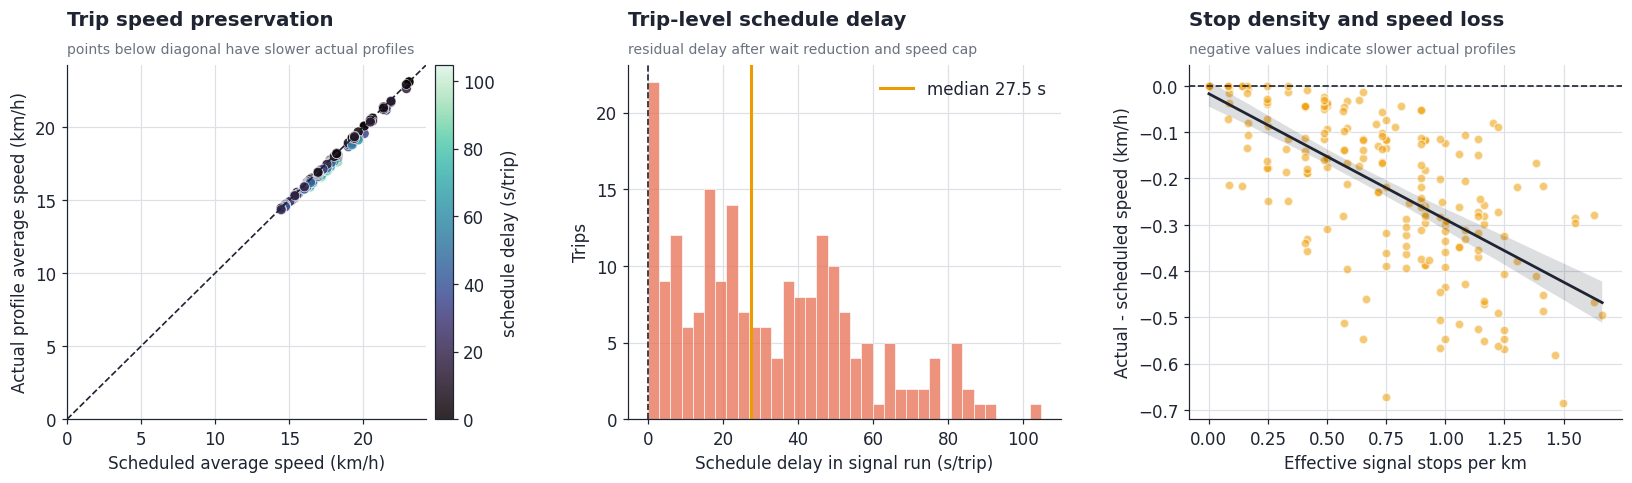

In [20]:

# Trip-level speed and delay diagnostics
required = {"scheduled_speed_kmh_on", "actual_profile_speed_kmh_on", "schedule_delay_min_on"}
if required.issubset(trip_pair.columns):
    speed_trip = trip_pair.copy()
    speed_trip["delay_s_on"] = speed_trip["schedule_delay_min_on"] * 60
    speed_trip["speed_loss_kmh_on"] = speed_trip["actual_profile_speed_kmh_on"] - speed_trip["scheduled_speed_kmh_on"]
    speed_trip["effective_stops_per_km_on"] = speed_trip["effective_signal_stops_on"] / speed_trip["dist_km_on"]

    fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.8))

    ax = axes[0]
    mx = np.nanmax([speed_trip.scheduled_speed_kmh_on.max(), speed_trip.actual_profile_speed_kmh_on.max()]) * 1.05
    sc = ax.scatter(speed_trip.scheduled_speed_kmh_on, speed_trip.actual_profile_speed_kmh_on,
                    c=speed_trip.delay_s_on, cmap=SEQ, s=42, alpha=.85,
                    edgecolor="white", linewidth=.4)
    ax.plot([0, mx], [0, mx], color=INK, lw=1.1, ls="--")
    ax.set_xlim(0, mx); ax.set_ylim(0, mx)
    ax.set_xlabel("Scheduled average speed (km/h)")
    ax.set_ylabel("Actual profile average speed (km/h)")
    cb = plt.colorbar(sc, ax=ax, pad=.02); cb.set_label("schedule delay (s/trip)")
    titled(ax, "Trip speed preservation", "points below diagonal have slower actual profiles")

    ax = axes[1]
    sns.histplot(speed_trip.delay_s_on, bins=35, color=ON, edgecolor="white", linewidth=.4, ax=ax)
    ax.axvline(0, color=INK, lw=1.1, ls="--")
    ax.axvline(speed_trip.delay_s_on.median(), color=ACC2, lw=2,
               label=f"median {speed_trip.delay_s_on.median():.1f} s")
    ax.set_xlabel("Schedule delay in signal run (s/trip)")
    ax.set_ylabel("Trips")
    ax.legend(loc="upper right")
    titled(ax, "Trip-level schedule delay", "residual delay after wait reduction and speed cap")

    ax = axes[2]
    sns.regplot(data=speed_trip, x="effective_stops_per_km_on", y="speed_loss_kmh_on",
                scatter_kws={"s": 32, "alpha": .55, "color": ACC2, "edgecolor": "white"},
                line_kws={"color": INK, "lw": 1.8}, ax=ax)
    ax.axhline(0, color=INK, lw=1.1, ls="--")
    ax.set_xlabel("Effective signal stops per km")
    ax.set_ylabel("Actual - scheduled speed (km/h)")
    titled(ax, "Stop density and speed loss", "negative values indicate slower actual profiles")

    tidy_layout(fig); savefig(fig, "03_trip_speed_delay"); plt.show()
else:
    print("Trip-level speed diagnostics skipped: refined timing columns are not available.")


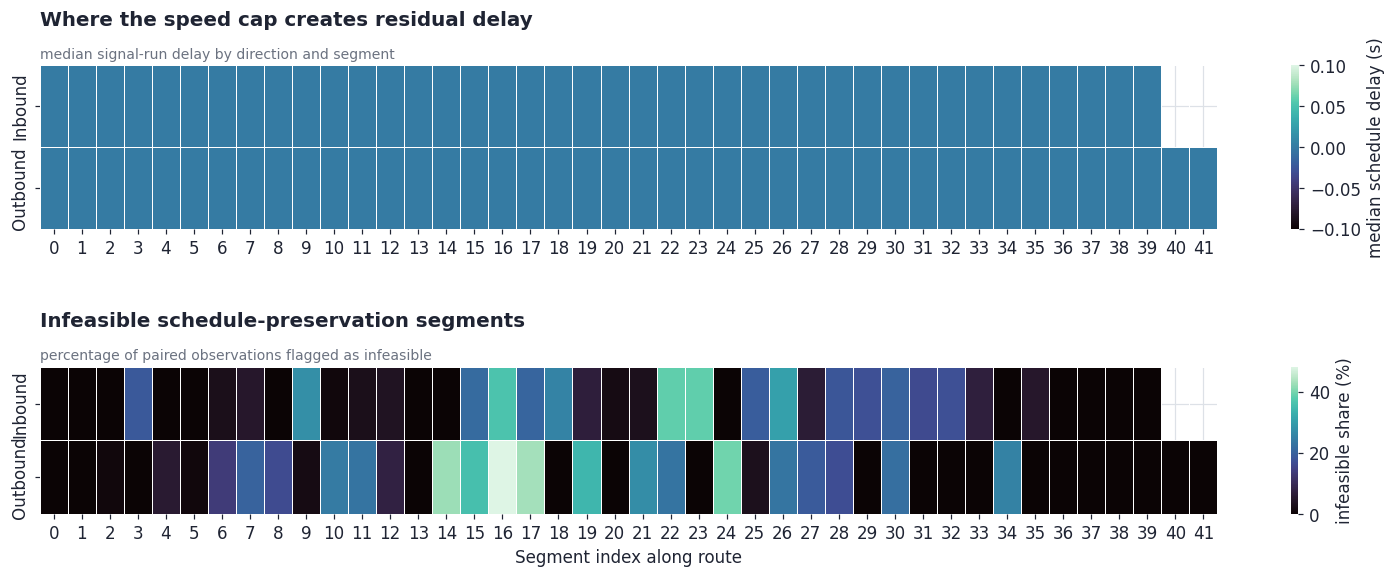

In [21]:

# Segment-level speed-cap and schedule-delay signature
required = {"schedule_delay_s_on", "dir_label_on", "segment", "n_signals_on", "signal_wait_s_on", "speed_loss_kmh_on", "schedule_infeasible_on"}
if required.issubset(seg_pair.columns):
    delay_profile = (seg_pair.assign(dir_label=seg_pair["dir_label_on"])
        .groupby(["dir_label", "segment"], observed=True)
        .agg(delay_s=("schedule_delay_s_on", "median"),
             signal_wait_s=("signal_wait_s_on", "median"),
             speed_loss_kmh=("speed_loss_kmh_on", "median"),
             signals=("n_signals_on", "median"),
             infeasible=("schedule_infeasible_on", lambda s: safe_bool_series(s).mean() * 100))
        .reset_index())

    delay_heat = delay_profile.pivot(index="dir_label", columns="segment", values="delay_s")
    infeasible_heat = delay_profile.pivot(index="dir_label", columns="segment", values="infeasible")

    fig, axes = plt.subplots(2, 1, figsize=(14.5, 5.8), gridspec_kw={"height_ratios": [1, .9]})

    ax = axes[0]
    sns.heatmap(delay_heat, cmap=SEQ, linewidths=.35, linecolor="white",
                cbar_kws={"label": "median schedule delay (s)"}, ax=ax)
    ax.set_xlabel(""); ax.set_ylabel("")
    titled(ax, "Where the speed cap creates residual delay", "median signal-run delay by direction and segment")

    ax = axes[1]
    sns.heatmap(infeasible_heat, cmap=SEQ, linewidths=.35, linecolor="white",
                cbar_kws={"label": "infeasible share (%)"}, ax=ax)
    ax.set_xlabel("Segment index along route"); ax.set_ylabel("")
    titled(ax, "Infeasible schedule-preservation segments", "percentage of paired observations flagged as infeasible")

    tidy_layout(fig); savefig(fig, "04_segment_speed_feasibility_heatmaps"); plt.show()
else:
    print("Segment-level speed feasibility diagnostics skipped: refined timing columns are not available.")


## 6. Energy balance: what changed physically?

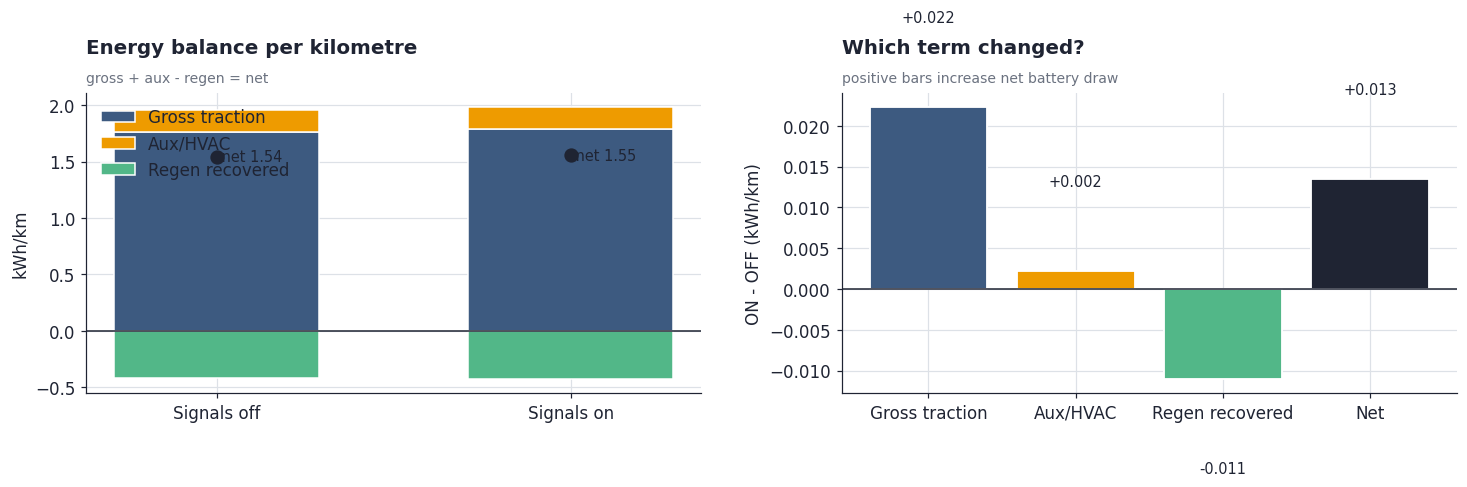

In [22]:
parts = summary[["gross_kWh", "aux_kWh", "regen_kWh", "net_kWh"]].copy()
parts_per_km = parts.div(summary["dist_km"], axis=0)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

ax = axes[0]
x = np.arange(2); width = 0.58; bottom = np.zeros(2)
for col, label, color in [("gross_kWh", "Gross traction", ACC), ("aux_kWh", "Aux/HVAC", ACC2)]:
    vals = parts_per_km.loc[["Signals off", "Signals on"], col].values
    ax.bar(x, vals, bottom=bottom, width=width, color=color, edgecolor="white", label=label)
    bottom += vals
regen = parts_per_km.loc[["Signals off", "Signals on"], "regen_kWh"].values
ax.bar(x, -regen, width=width, color=REGEN, edgecolor="white", label="Regen recovered")
net = parts_per_km.loc[["Signals off", "Signals on"], "net_kWh"].values
for xi, nv in zip(x, net):
    ax.scatter(xi, nv, s=70, color=INK, zorder=5)
    ax.text(xi, nv, f" net {nv:.2f}", ha="left", va="center", fontsize=9.5, color=INK)
ax.axhline(0, color=INK, lw=1)
ax.set_xticks(x); ax.set_xticklabels(["Signals off", "Signals on"])
ax.set_ylabel("kWh/km"); ax.legend(loc="upper left")
titled(ax, "Energy balance per kilometre", "gross + aux - regen = net")

ax = axes[1]
delta_parts = parts_per_km.loc["Signals on"] - parts_per_km.loc["Signals off"]
labels = ["Gross traction", "Aux/HVAC", "Regen recovered", "Net"]
vals = [delta_parts.gross_kWh, delta_parts.aux_kWh, -delta_parts.regen_kWh, delta_parts.net_kWh]
ax.bar(labels, vals, color=[ACC, ACC2, REGEN, INK], edgecolor="white", linewidth=1.2)
ax.axhline(0, color=INK, lw=1)
for i, v in enumerate(vals):
    ax.text(i, v + (0.01 if v >= 0 else -0.01), f"{v:+.3f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=9.5)
ax.set_ylabel("ON - OFF (kWh/km)")
titled(ax, "Which term changed?", "positive bars increase net battery draw")
tidy_layout(fig); savefig(fig, "02_energy_balance_delta"); plt.show()


## 7. Trip-level paired comparison

C:\Users\ninglin.ou\AppData\Local\Temp\ipykernel_2628\3445743070.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  plot_df = trip_pair.assign(dir_label=trip_pair["dir_label_on"])


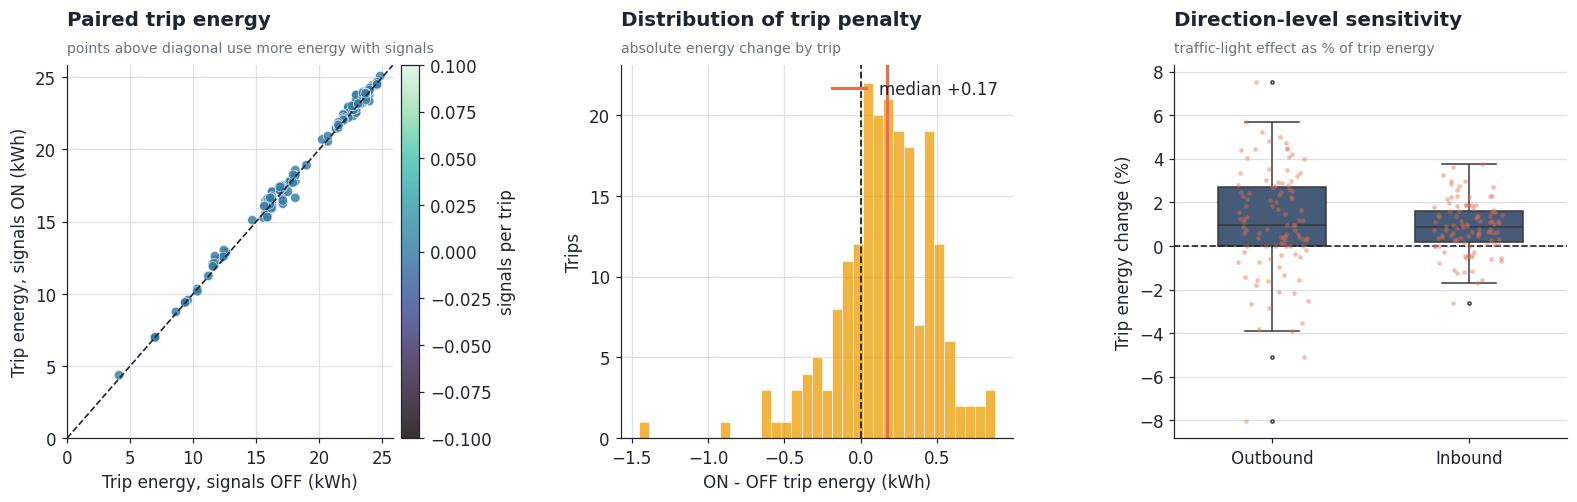

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ax = axes[0]
mx = max(trip_pair.net_kWh_off.max(), trip_pair.net_kWh_on.max()) * 1.03
sc0 = ax.scatter(trip_pair.net_kWh_off, trip_pair.net_kWh_on, c=trip_pair.n_signals_on,
                 cmap=SEQ, s=38, alpha=.82, edgecolor="white", linewidth=.4)
ax.plot([0, mx], [0, mx], color=INK, lw=1.1, ls="--")
ax.set_xlim(0, mx); ax.set_ylim(0, mx)
ax.set_xlabel("Trip energy, signals OFF (kWh)"); ax.set_ylabel("Trip energy, signals ON (kWh)")
titled(ax, "Paired trip energy", "points above diagonal use more energy with signals")
cb = plt.colorbar(sc0, ax=ax, pad=.02); cb.set_label("signals per trip")

ax = axes[1]
sns.histplot(trip_pair.delta_net_kWh, bins=35, color=ACC2, edgecolor="white", linewidth=.4, ax=ax)
ax.axvline(0, color=INK, lw=1.2, ls="--")
ax.axvline(trip_pair.delta_net_kWh.median(), color=ON, lw=2, label=f"median {trip_pair.delta_net_kWh.median():+.2f}")
ax.set_xlabel("ON - OFF trip energy (kWh)"); ax.set_ylabel("Trips"); ax.legend(loc="upper right")
titled(ax, "Distribution of trip penalty", "absolute energy change by trip")

ax = axes[2]
plot_df = trip_pair.assign(dir_label=trip_pair["dir_label_on"])
sns.boxplot(data=plot_df, x="dir_label", y="delta_pct_energy", color=ACC, width=.55, fliersize=2, linewidth=1, ax=ax)
sns.stripplot(data=plot_df, x="dir_label", y="delta_pct_energy", color=ON, size=3, alpha=.45, jitter=.18, ax=ax)
ax.axhline(0, color=INK, lw=1.1, ls="--")
ax.set_xlabel(""); ax.set_ylabel("Trip energy change (%)")
titled(ax, "Direction-level sensitivity", "traffic-light effect as % of trip energy")
tidy_layout(fig); savefig(fig, "03_trip_paired_comparison"); plt.show()


## 8. Time-of-day profile

C:\Users\ninglin.ou\AppData\Local\Temp\ipykernel_2628\393526283.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  hourly = (trip_pair.assign(dir_label=trip_pair["dir_label_on"])


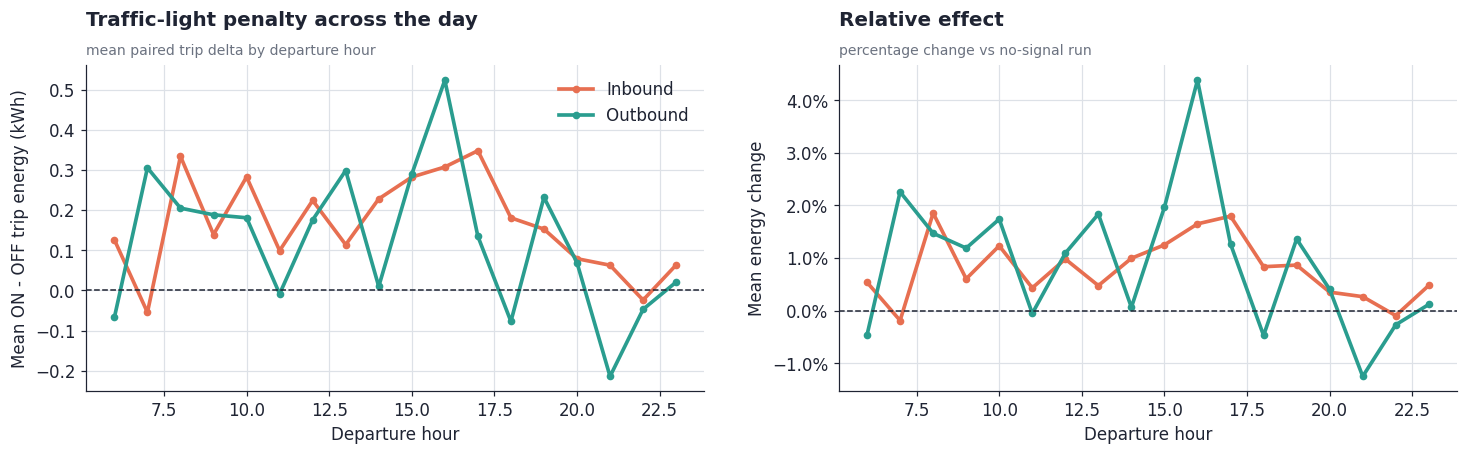

In [24]:
hourly = (trip_pair.assign(dir_label=trip_pair["dir_label_on"])
    .groupby(["dep_hour_on", "dir_label"], observed=True)
    .agg(delta_kWh=("delta_net_kWh", "mean"), delta_pct=("delta_pct_energy", "mean"),
         trips=("trip_id", "count"), signals=("n_signals_on", "mean"))
    .reset_index())
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharex=True)

ax = axes[0]
for dlab, g in hourly.groupby("dir_label", observed=True):
    c = OFF if dlab == "Outbound" else ON
    ax.plot(g.dep_hour_on, g.delta_kWh, color=c, lw=2.4, marker="o", ms=4, label=dlab)
ax.axhline(0, color=INK, lw=1, ls="--")
ax.set_xlabel("Departure hour"); ax.set_ylabel("Mean ON - OFF trip energy (kWh)"); ax.legend(title="")
titled(ax, "Traffic-light penalty across the day", "mean paired trip delta by departure hour")

ax = axes[1]
for dlab, g in hourly.groupby("dir_label", observed=True):
    c = OFF if dlab == "Outbound" else ON
    ax.plot(g.dep_hour_on, g.delta_pct, color=c, lw=2.4, marker="o", ms=4, label=dlab)
ax.axhline(0, color=INK, lw=1, ls="--")
ax.yaxis.set_major_formatter(PercentFormatter())
ax.set_xlabel("Departure hour"); ax.set_ylabel("Mean energy change")
titled(ax, "Relative effect", "percentage change vs no-signal run")
tidy_layout(fig); savefig(fig, "07_time_of_day_delta"); plt.show()


## 9. Segment-level spatial signature

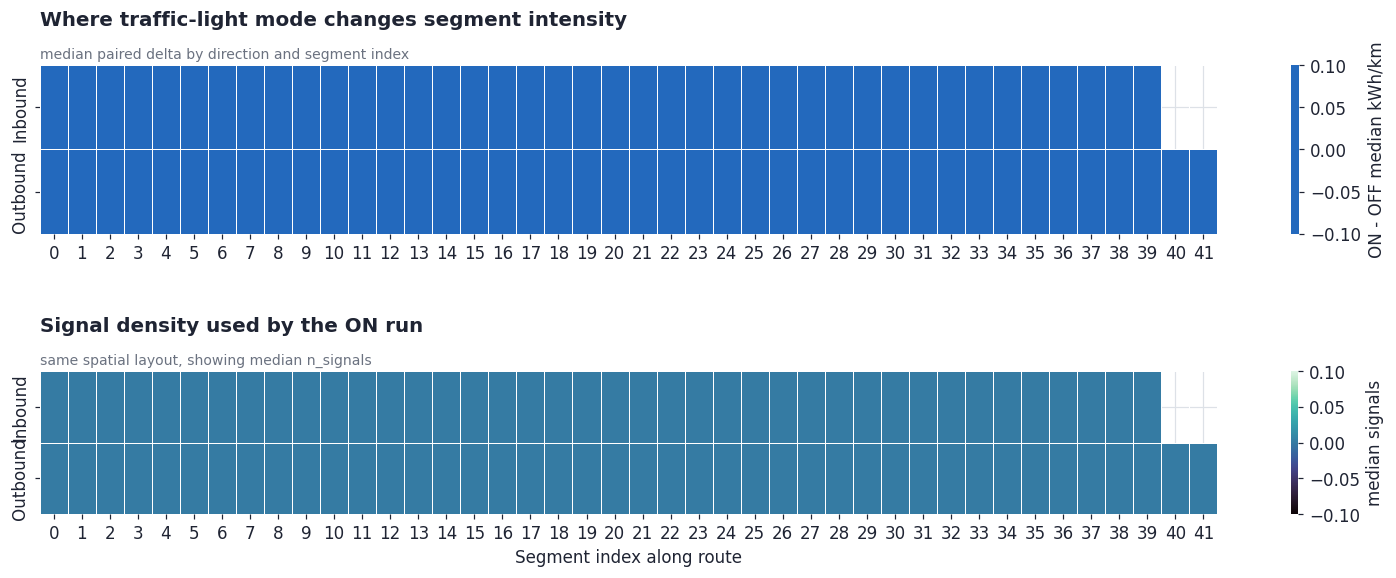

In [25]:
seg_profile = (seg_pair.assign(dir_label=seg_pair["dir_label_on"])
    .groupby(["dir_label", "segment"], observed=True)
    .agg(delta_kWh_km=("delta_net_battery_kWh_per_km", "median"),
         delta_kWh=("delta_net_battery_energy_kWh", "median"), signals=("n_signals_on", "median"), n=("trip_id", "count"))
    .reset_index())
heat = seg_profile.pivot(index="dir_label", columns="segment", values="delta_kWh_km")
sig_heat = seg_profile.pivot(index="dir_label", columns="segment", values="signals")

fig, axes = plt.subplots(2, 1, figsize=(14.5, 5.8), gridspec_kw={"height_ratios": [1.0, .85]})
ax = axes[0]
lim = np.nanpercentile(np.abs(heat.values), 95) if np.isfinite(heat.values).any() else 1
sns.heatmap(heat, cmap=DIV, center=0, vmin=-lim, vmax=lim, linewidths=.35, linecolor="white",
            cbar_kws={"label": "ON - OFF median kWh/km"}, ax=ax)
ax.set_xlabel(""); ax.set_ylabel("")
titled(ax, "Where traffic-light mode changes segment intensity", "median paired delta by direction and segment index")

ax = axes[1]
sns.heatmap(sig_heat, cmap=SEQ, linewidths=.35, linecolor="white", cbar_kws={"label": "median signals"}, ax=ax)
ax.set_xlabel("Segment index along route"); ax.set_ylabel("")
titled(ax, "Signal density used by the ON run", "same spatial layout, showing median n_signals")
tidy_layout(fig); savefig(fig, "08_segment_heatmaps"); plt.show()


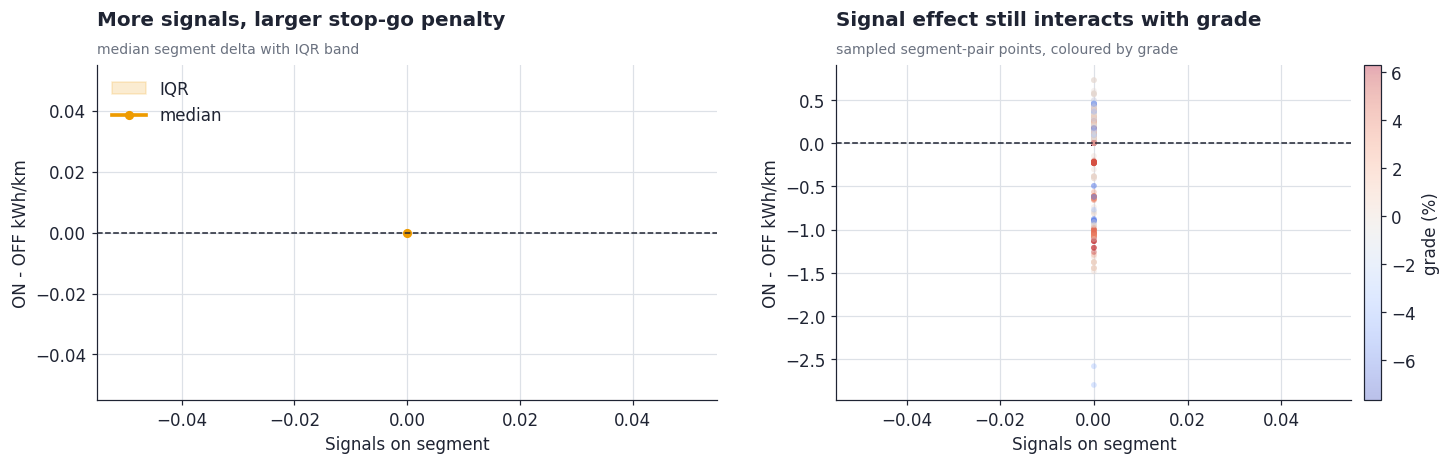

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
ax = axes[0]
seg_bins = (seg_pair.groupby("n_signals_on", observed=True)
    .agg(delta_kWh_km=("delta_net_battery_kWh_per_km", "median"),
         q1=("delta_net_battery_kWh_per_km", lambda s: s.quantile(.25)),
         q3=("delta_net_battery_kWh_per_km", lambda s: s.quantile(.75)), n=("trip_id", "count"))
    .reset_index())
ax.fill_between(seg_bins.n_signals_on, seg_bins.q1, seg_bins.q3, color=ACC2, alpha=.18, label="IQR")
ax.plot(seg_bins.n_signals_on, seg_bins.delta_kWh_km, color=ACC2, lw=2.4, marker="o", ms=5, label="median")
ax.axhline(0, color=INK, lw=1, ls="--")
ax.set_xlabel("Signals on segment"); ax.set_ylabel("ON - OFF kWh/km"); ax.legend(loc="upper left")
titled(ax, "More signals, larger stop-go penalty", "median segment delta with IQR band")

ax = axes[1]
sample = seg_pair.sample(min(len(seg_pair), 6000), random_state=7) if len(seg_pair) else seg_pair
sc = ax.scatter(sample.n_signals_on, sample.delta_net_battery_kWh_per_km, c=sample["grade_%_on"],
                cmap="coolwarm", s=14, alpha=.35, edgecolor="none")
ax.axhline(0, color=INK, lw=1, ls="--")
ax.set_xlabel("Signals on segment"); ax.set_ylabel("ON - OFF kWh/km")
cb = plt.colorbar(sc, ax=ax, pad=.02); cb.set_label("grade (%)")
titled(ax, "Signal effect still interacts with grade", "sampled segment-pair points, coloured by grade")
tidy_layout(fig); savefig(fig, "09_signal_count_vs_delta"); plt.show()


## 10. Duty-level operational impact

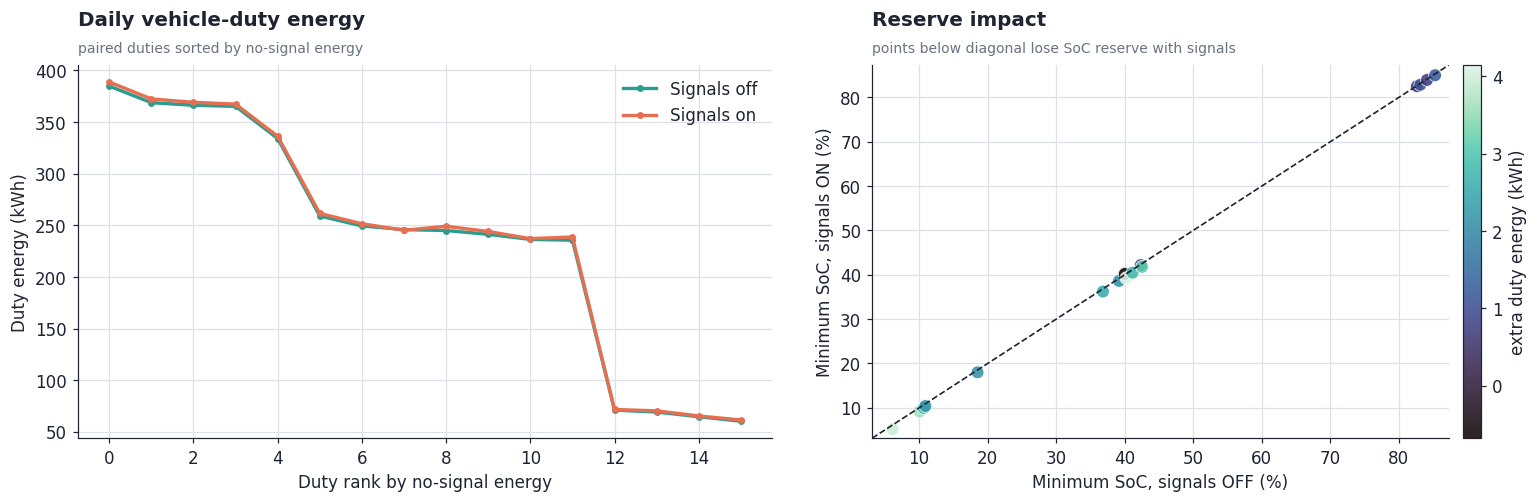

In [27]:
if duty_pair.empty:
    print("No paired duties found; skipping duty-level comparison.")
else:
    duty_plot = duty_pair.sort_values("net_kWh_off", ascending=False).reset_index(drop=True)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.0))
    ax = axes[0]
    x = np.arange(len(duty_plot))
    ax.plot(x, duty_plot.net_kWh_off, color=OFF, lw=2.2, marker="o", ms=3.5, label="Signals off")
    ax.plot(x, duty_plot.net_kWh_on, color=ON, lw=2.2, marker="o", ms=3.5, label="Signals on")
    ax.fill_between(x, duty_plot.net_kWh_off, duty_plot.net_kWh_on, color=ACC2, alpha=.13)
    ax.set_xlabel("Duty rank by no-signal energy"); ax.set_ylabel("Duty energy (kWh)"); ax.legend(loc="upper right")
    titled(ax, "Daily vehicle-duty energy", "paired duties sorted by no-signal energy")

    ax = axes[1]
    sc = ax.scatter(duty_plot.soc_min_off, duty_plot.soc_min_on, c=duty_plot.delta_net_kWh,
                    cmap=SEQ, s=70, alpha=.88, edgecolor="white", linewidth=.5)
    lo = min(duty_plot.soc_min_off.min(), duty_plot.soc_min_on.min()) - 2
    hi = max(duty_plot.soc_min_off.max(), duty_plot.soc_min_on.max()) + 2
    ax.plot([lo, hi], [lo, hi], color=INK, lw=1.1, ls="--")
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel("Minimum SoC, signals OFF (%)"); ax.set_ylabel("Minimum SoC, signals ON (%)")
    cb = plt.colorbar(sc, ax=ax, pad=.02); cb.set_label("extra duty energy (kWh)")
    titled(ax, "Reserve impact", "points below diagonal lose SoC reserve with signals")
    tidy_layout(fig); savefig(fig, "10_duty_operational_impact"); plt.show()


## 11. Largest affected trips and segments

In [28]:

def existing_cols(df, cols):
    return [c for c in cols if c in df.columns]

trip_cols = existing_cols(trip_pair, [
    "trip_id", "duty_id_on", "dir_label_on", "trip_start_time_on",
    "dist_km_on", "n_signals_on", "effective_signal_stops_on",
    "signal_wait_min_on", "signal_wait_reduced_min_on", "schedule_delay_min_on",
    "scheduled_speed_kmh_on", "actual_profile_speed_kmh_on", "moving_profile_speed_kmh_on",
    "infeasible_segments_on", "net_kWh_off", "net_kWh_on",
    "delta_net_kWh", "delta_pct_energy",
])
print("Trips with the largest extra energy from traffic-light mode")
display(trip_pair.sort_values("delta_net_kWh", ascending=False)[trip_cols].head(12).round(3))

print("\nTrips with the largest residual schedule delay in traffic-light mode")
delay_cols = existing_cols(trip_pair, [
    "trip_id", "duty_id_on", "dir_label_on", "trip_start_time_on",
    "dist_km_on", "n_signals_on", "effective_signal_stops_on",
    "signal_wait_min_on", "signal_wait_reduced_min_on", "schedule_delay_min_on",
    "scheduled_speed_kmh_on", "actual_profile_speed_kmh_on", "infeasible_segments_on",
    "delta_net_kWh",
])
if "schedule_delay_min_on" in trip_pair.columns:
    display(trip_pair.sort_values("schedule_delay_min_on", ascending=False)[delay_cols].head(12).round(3))
else:
    print("schedule_delay_min_on is not available.")

seg_cols_out = existing_cols(seg_pair, [
    "trip_id", "segment", "dir_label_on", "dep_hour_on", "length_m_on",
    "grade_%_on", "passengers_on", "n_signals_on", "n_effective_signal_stops_on",
    "signal_wait_s_on", "signal_wait_reduced_s_on", "schedule_delay_s_on",
    "scheduled_speed_kmh_on", "actual_profile_speed_kmh_on", "moving_profile_speed_kmh_on",
    "speed_cap_kmh_on", "schedule_infeasible_on",
    "net_battery_energy_kWh_off", "net_battery_energy_kWh_on",
    "delta_net_battery_energy_kWh", "delta_net_battery_kWh_per_km",
])
print("\nSegments with the largest extra energy from traffic-light mode")
display(seg_pair.sort_values("delta_net_battery_energy_kWh", ascending=False)[seg_cols_out].head(15).round(3))

print("\nSegments with the largest residual schedule delay in traffic-light mode")
if "schedule_delay_s_on" in seg_pair.columns:
    display(seg_pair.sort_values("schedule_delay_s_on", ascending=False)[seg_cols_out].head(15).round(3))
else:
    print("schedule_delay_s_on is not available.")


Trips with the largest extra energy from traffic-light mode


,trip_id,duty_id_on,dir_label_on,trip_start_time_on,dist_km_on,n_signals_on,effective_signal_stops_on,signal_wait_min_on,signal_wait_reduced_min_on,schedule_delay_min_on,scheduled_speed_kmh_on,actual_profile_speed_kmh_on,moving_profile_speed_kmh_on,infeasible_segments_on,net_kWh_off,net_kWh_on,delta_net_kWh,delta_pct_energy
66,5695_42027,234:5695_7778208_42080210,Outbound,16:25:00,12.024,0.0,17,0.996,2.879,0.673,15.350,15.134,15.457,8,11.728,12.610,0.882,7.520
130,5695_43379,234:5695_7778208_42080201,Inbound,10:20:00,12.283,0.0,19,0.912,3.613,0.680,17.759,17.473,17.859,8,22.940,23.802,0.862,3.758
144,5695_43684,234:5695_7778208_42080203,Inbound,12:30:00,12.283,0.0,16,1.325,2.600,0.518,17.759,17.540,18.111,6,22.940,23.776,0.836,3.644
46,5695_41589,234:5695_7778208_42080205,Outbound,13:15:00,12.024,0.0,17,0.861,2.764,1.222,17.178,16.692,17.031,9,16.263,17.077,0.814,5.005
45,5695_41567,234:5695_7778208_42080201,Outbound,13:05:00,12.024,0.0,14,0.603,2.597,0.741,17.178,16.880,17.121,7,16.263,17.048,0.785,4.827
22,5695_41070,234:5695_7778208_42080205,Outbound,09:35:00,12.024,0.0,14,1.086,2.039,0.641,17.178,16.919,17.361,6,15.754,16.465,0.711,4.513
28,5695_41193,234:5695_7778208_42080204,Outbound,10:25:00,12.024,0.0,13,0.903,1.897,0.777,17.178,16.866,17.230,5,15.900,16.601,0.701,4.409
40,5695_41455,234:5695_7778208_42080204,Outbound,12:15:00,12.024,0.0,13,0.925,2.250,0.508,17.178,16.972,17.350,6,15.900,16.574,0.674,4.239
159,5695_44019,234:5695_7778208_42080212,Inbound,15:00:00,12.283,0.0,15,1.046,2.704,0.248,16.198,16.110,16.487,6,22.316,22.981,0.665,2.980
160,5695_44040,234:5695_7778208_42080204,Inbound,15:10:00,12.283,0.0,17,1.792,2.133,0.471,16.198,16.032,16.682,5,22.316,22.928,0.612,2.742



Trips with the largest residual schedule delay in traffic-light mode


,trip_id,duty_id_on,dir_label_on,trip_start_time_on,dist_km_on,n_signals_on,effective_signal_stops_on,signal_wait_min_on,signal_wait_reduced_min_on,schedule_delay_min_on,scheduled_speed_kmh_on,actual_profile_speed_kmh_on,infeasible_segments_on,delta_net_kWh
35,5695_41342,234:5695_7778208_42080205,Outbound,11:25:00,12.024,0.0,18,0.340,3.410,1.745,17.178,16.492,12,-0.031
77,5695_42258,234:5695_7778208_42080212,Outbound,17:55:00,12.024,0.0,9,0.500,1.375,1.511,18.265,17.592,7,-1.456
53,5695_41744,234:5695_7778208_42080210,Outbound,14:25:00,12.024,0.0,15,0.476,2.974,1.465,16.397,15.868,10,-0.157
145,5695_43705,234:5695_7778208_42080206,Inbound,12:40:00,12.283,0.0,18,0.857,3.193,1.439,17.548,16.966,8,-0.261
51,5695_41701,234:5695_7778208_42080204,Outbound,14:05:00,12.024,0.0,15,0.524,2.451,1.435,17.178,16.610,9,-0.231
48,5695_41634,234:5695_7778208_42080206,Outbound,13:35:00,12.024,0.0,14,0.524,2.676,1.392,17.178,16.627,11,-0.341
150,5695_43818,234:5695_7778208_42080210,Inbound,13:30:00,12.283,0.0,15,0.609,2.841,1.389,17.548,16.986,9,-0.098
41,5695_41476,234:5695_7778208_42080207,Outbound,12:25:00,12.024,0.0,15,0.336,2.639,1.382,17.178,16.630,9,-0.056
34,5695_41321,234:5695_7778208_42080201,Outbound,11:15:00,12.024,0.0,12,0.525,2.175,1.378,17.178,16.632,9,-0.621
124,5695_43256,234:5695_7778208_42080204,Inbound,09:30:00,12.283,0.0,12,0.500,2.125,1.369,17.759,17.192,9,-0.358



Segments with the largest extra energy from traffic-light mode


,trip_id,segment,dir_label_on,dep_hour_on,length_m_on,grade_%_on,passengers_on,n_signals_on,n_effective_signal_stops_on,signal_wait_s_on,...,schedule_delay_s_on,scheduled_speed_kmh_on,actual_profile_speed_kmh_on,moving_profile_speed_kmh_on,speed_cap_kmh_on,schedule_infeasible_on,net_battery_energy_kWh_off,net_battery_energy_kWh_on,delta_net_battery_energy_kWh,delta_net_battery_kWh_per_km
4462,5695_41723,19,Outbound,14,398.2,-0.25,75,0.0,2,0.0,...,13.163,23.892,19.594,19.594,27.479,True,0.333,0.623,0.290,0.727
3688,5695_41589,19,Outbound,13,398.2,-0.25,75,0.0,2,0.0,...,13.163,23.892,19.594,19.594,27.479,True,0.333,0.623,0.290,0.727
1031,5695_41567,19,Outbound,13,398.2,-0.25,75,0.0,2,0.0,...,13.163,23.892,19.594,19.594,27.479,True,0.333,0.623,0.290,0.727
6872,5695_41677,19,Outbound,13,398.2,-0.25,75,0.0,2,0.0,...,13.163,23.892,19.594,19.594,27.479,True,0.333,0.623,0.290,0.727
3768,5695_41857,24,Outbound,15,439.0,-0.23,66,0.0,2,0.0,...,15.314,26.340,20.984,20.984,30.294,True,0.395,0.660,0.265,0.604
1469,5695_41388,24,Outbound,11,439.0,-0.23,53,0.0,2,0.0,...,15.314,26.340,20.984,20.984,30.294,True,0.380,0.633,0.253,0.576
2622,5695_41193,24,Outbound,10,439.0,-0.23,53,0.0,2,0.0,...,15.314,26.340,20.984,20.984,30.294,True,0.380,0.633,0.253,0.576
6577,5695_41097,24,Outbound,9,439.0,-0.23,53,0.0,2,0.0,...,15.314,26.340,20.984,20.984,30.294,True,0.380,0.633,0.253,0.576
157,5695_41096,24,Outbound,9,439.0,-0.23,53,0.0,2,0.0,...,15.314,26.340,20.984,20.984,30.294,True,0.380,0.633,0.253,0.576
7294,5695_41909,7,Outbound,15,439.0,-0.23,49,0.0,2,0.0,...,15.314,26.340,20.984,20.984,30.294,True,0.376,0.624,0.248,0.566



Segments with the largest residual schedule delay in traffic-light mode


,trip_id,segment,dir_label_on,dep_hour_on,length_m_on,grade_%_on,passengers_on,n_signals_on,n_effective_signal_stops_on,signal_wait_s_on,...,schedule_delay_s_on,scheduled_speed_kmh_on,actual_profile_speed_kmh_on,moving_profile_speed_kmh_on,speed_cap_kmh_on,schedule_infeasible_on,net_battery_energy_kWh_off,net_battery_energy_kWh_on,delta_net_battery_energy_kWh,delta_net_battery_kWh_per_km
7012,5695_42258,9,Outbound,17,429.1,-3.96,32,0.0,1,0.0,...,26.093,51.492,27.539,27.539,59.209,True,1.597,0.398,-1.199,-2.796
5329,5695_42388,9,Outbound,18,429.1,-3.96,16,0.0,1,0.0,...,26.093,51.492,27.539,27.539,59.209,True,1.470,0.364,-1.106,-2.579
2502,5695_42981,16,Inbound,7,279.9,0.00,45,0.0,2,0.0,...,25.484,33.588,18.161,18.161,38.621,True,0.806,0.764,-0.042,-0.149
5308,5695_44425,28,Inbound,17,368.6,5.70,41,0.0,1,0.0,...,21.995,44.232,25.521,25.521,50.875,True,2.206,1.796,-0.410,-1.114
1508,5695_43705,25,Inbound,12,368.6,5.70,55,0.0,1,0.0,...,21.995,44.232,25.521,25.521,50.875,True,2.341,1.895,-0.446,-1.210
3657,5695_43662,25,Inbound,12,368.6,5.70,44,0.0,1,0.0,...,21.995,44.232,25.521,25.521,50.875,True,2.235,1.817,-0.418,-1.134
5690,5695_44086,25,Inbound,15,368.6,5.70,55,0.0,1,0.0,...,21.995,44.232,25.521,25.521,50.875,True,2.341,1.895,-0.446,-1.210
2982,5695_42964,25,Inbound,7,368.6,5.70,33,0.0,1,0.0,...,21.995,44.232,25.521,25.521,50.875,True,2.130,1.739,-0.391,-1.060
1358,5695_43193,25,Inbound,9,368.6,5.70,39,0.0,1,0.0,...,21.995,44.232,25.521,25.521,50.875,True,2.187,1.781,-0.406,-1.100
5226,5695_44107,25,Inbound,15,368.6,5.70,62,0.0,1,0.0,...,21.995,44.232,25.521,25.521,50.875,True,2.409,1.944,-0.465,-1.259


## 12. Interpretation checklist

Use this section when deciding whether the traffic-light model is ready for validation:

1. Magnitude: is the total energy increase plausible relative to expected stop-go losses?
2. Energy balance: is most of the change in gross traction and regeneration rather than auxiliary energy?
3. Speed preservation: does `actual_profile_time_h` stay close to `scheduled_run_time_h`?
4. Feasibility: are `schedule_delay_h`, `schedule_delay_s_per_trip`, and `infeasible_segments_%` acceptably low?
5. Wait reduction: is `signal_wait_reduced_h` large when the GTFS schedule cannot accommodate all requested red-light waits?
6. Spatial pattern: do high energy and delay deltas appear on segments with known signals and crossings?
7. SoC reserve: do any duties become infeasible only because traffic-light mode is enabled?

If the segment heatmap shows zero signal counts in known suburban crossing areas, refresh the signal cache after the updated `traffic_signals.py` fetch logic, then rerun this notebook. If the speed diagnostics show many infeasible segments, revisit the signal speed-cap assumption before treating the energy comparison as validation-ready.
